# UC3 — Frugality & Carbon Footprint Benchmark


This notebook compares several ML models along two axes:
- **Performance** (AUC-ROC, F1)
- **Computational cost** (training time, estimated CO₂ footprint)

It also explores **data frugality**: how many features are actually necessary?

### Prerequisites
Run UC2 first to generate `HRDataset_anonymized.csv`.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, f1_score


try:
    from codecarbon import EmissionsTracker
    CODECARBON = True
    print("CodeCarbon available")
except ImportError:
    CODECARBON = False
    
try:
    from xgboost import XGBClassifier
    XGBOOST = True
    print("XGBoost available")
except ImportError:
    XGBOOST = False
    print("XGBoost not installed")

try:
    from catboost import CatBoostClassifier
    CATBOOST = True
    print("CatBoost available")
except ImportError:
    CATBOOST = False
    print("CatBoost not installed")

# Load anonymized dataset
try:
    df = pd.read_csv('HRDataset_anonymized.csv')
    print(f"Anonymized dataset loaded: {df.shape}")
except FileNotFoundError:
    raise FileNotFoundError("File 'HRDataset_anonymized.csv' not found.")

CodeCarbon available
XGBoost available
CatBoost available
Anonymized dataset loaded: (311, 34)


## 1. Feature Engineering (identical to UC1 for consistency)

In [31]:
ref_date = pd.Timestamp('2019-01-01')

df['DateofHire'] = pd.to_datetime(df['DateofHire'], errors='coerce')
df['tenure_years'] = ((ref_date - df['DateofHire']).dt.days / 365.25).clip(lower=0)

def bracket_to_midpoint(b):
    try:
        parts = str(b).replace('k', '').split('-')
        return (int(parts[0]) + int(parts[1])) / 2 * 1000
    except:
        return np.nan

def age_bracket_to_mid(b):
    try:
        parts = str(b).split('-')
        return (int(parts[0]) + int(parts[1])) / 2
    except:
        return np.nan

df['salary_mid'] = df['salary_bracket'].apply(bracket_to_midpoint)
df['age_mid'] = df['age_bracket'].apply(age_bracket_to_mid)

dept_salary_mean = df.groupby('Department')['salary_mid'].transform('mean')
df['salary_ratio_dept'] = df['salary_mid'] / dept_salary_mean

dept_tenure_mean = df.groupby('Department')['tenure_years'].transform('mean')
df['tenure_ratio_dept'] = df['tenure_years'] / (dept_tenure_mean + 0.01)

df['manager_turnover_rate'] = df.groupby('ManagerID')['Termd'].transform('mean')
df['absences_per_year'] = df['Absences'] / (df['tenure_years'] + 0.5)
df['low_sat_high_abs'] = ((df['EmpSatisfaction'] <= 2) & (df['Absences'] > 10)).astype(int)

df['risk_score'] = (
    (5 - df['EngagementSurvey'])
    + (5 - df['EmpSatisfaction'])
    + (df['DaysLateLast30'].clip(0, 10) / 2)
    + (df['Absences'] / 10)
    + np.where(df['PerfScoreID'] <= 2, 2.0, 0.0)
    + np.where(df['SpecialProjectsCount'] == 0, 0.5, 0.0)
).clip(lower=0)

FEATURES_ALL = [
    'GenderID', 'MarriedID', 'PerfScoreID', 'FromDiversityJobFairID',
    'DeptID', 'PositionID', 'EngagementSurvey', 'EmpSatisfaction',
    'SpecialProjectsCount', 'DaysLateLast30', 'Absences',
    'tenure_years', 'age_mid', 'salary_ratio_dept', 'risk_score',
    'tenure_ratio_dept', 'manager_turnover_rate', 'absences_per_year', 'low_sat_high_abs'
]
TARGET = 'Termd'

df_model = df[FEATURES_ALL + [TARGET]].dropna()
X = df_model[FEATURES_ALL]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train : {len(X_train)} | Test : {len(X_test)} | Features : {len(FEATURES_ALL)}")

Train : 164 | Test : 41 | Features : 19


## 2. Model definitions for comparison

In [19]:
models = {
    'Logistic Regression\n(frugal ★★★)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
    ]),
    'Decision Tree\n(frugal ★★★)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced'))
    ]),
    'Random Forest\n(moderate ★★)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
    ]),
    'Gradient Boosting\n(heavy ★)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier(n_estimators=200, random_state=42))
    ]),
}

if XGBOOST:
    models['XGBoost\n(heavy ★)'] = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', XGBClassifier(n_estimators=200, random_state=42,
                              use_label_encoder=False, eval_metric='logloss',
                              scale_pos_weight=1, verbosity=0))
    ])

if CATBOOST:
    models['CatBoost\n(heavy ★)'] = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', CatBoostClassifier(iterations=200, random_seed=42,
                                   verbose=0, auto_class_weights='Balanced'))
    ])

print(f"{len(models)} models to compare.")

6 models to compare.


## 3. Training and resource measurement


In [ ]:
results = []

for name, pipe in models.items():
    print(f"Training: {name.replace(chr(10), ' ')}...")

    if CODECARBON:
        tracker = EmissionsTracker(project_name=name, log_level='error')
        tracker.start()

    t0 = time.perf_counter()
    pipe.fit(X_train, y_train)
    elapsed = time.perf_counter() - t0

    if CODECARBON:
        emissions_kg = tracker.stop()
        emissions_g = emissions_kg * 1000
    else:
        # proxy: 1s CPU ~ 0.04g CO₂ (40g/kWh, European cloud server)
        emissions_g = elapsed * 0.04

    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    f1  = f1_score(y_test, y_pred, average='weighted')

    clf = pipe.named_steps['clf']
    if hasattr(clf, 'coef_'):
        n_params = clf.coef_.size
    elif hasattr(clf, 'estimators_') and hasattr(clf.estimators_[0], 'tree_'):
        n_params = sum(e.tree_.node_count for e in clf.estimators_)
    elif hasattr(clf, 'tree_'):
        n_params = clf.tree_.node_count
    else:
        n_params = 200

    results.append({
        'Model': name,
        'AUC-ROC': round(auc, 4),
        'F1': round(f1, 4),
        'Time (s)': round(elapsed, 4),
        'CO₂ estimated (g)': round(emissions_g, 6),
        'N parameters': n_params,
        'CO₂ method': 'CodeCarbon' if CODECARBON else 'CPU Proxy'
    })
    print(f"   AUC={auc:.3f} | F1={f1:.3f} | Time={elapsed:.3f}s | CO₂={emissions_g:.4f}g")

df_results = pd.DataFrame(results)
print(df_results[['Model', 'AUC-ROC', 'F1', 'Time (s)', 'CO₂ estimated (g)', 'N parameters']].to_string(index=False))

Training: Logistic Regression (frugal ★★★)...
   AUC=0.887 | F1=0.808 | Time=0.014s | CO₂=0.0013g
Training: Decision Tree (frugal ★★★)...
   AUC=0.837 | F1=0.810 | Time=0.009s | CO₂=0.0006g
Training: Random Forest (moderate ★★)...
   AUC=0.940 | F1=0.794 | Time=0.200s | CO₂=0.0010g
Training: Gradient Boosting (heavy ★)...
   AUC=0.874 | F1=0.822 | Time=0.344s | CO₂=0.0008g
Training: XGBoost (heavy ★)...
   AUC=0.907 | F1=0.831 | Time=60.168s | CO₂=0.1078g
Training: CatBoost (heavy ★)...
   AUC=0.904 | F1=0.827 | Time=0.270s | CO₂=0.0011g
                            Model  AUC-ROC     F1  Time (s)  CO₂ estimated (g)  N parameters
Logistic Regression\n(frugal ★★★)   0.8874 0.8082    0.0143           0.001290            19
      Decision Tree\n(frugal ★★★)   0.8365 0.8104    0.0091           0.000562            33
     Random Forest\n(moderate ★★)   0.9396 0.7936    0.1997           0.000957          5704
     Gradient Boosting\n(heavy ★)   0.8736 0.8225    0.3438           0.000804      

## 4. Visualization — Performance vs Resources

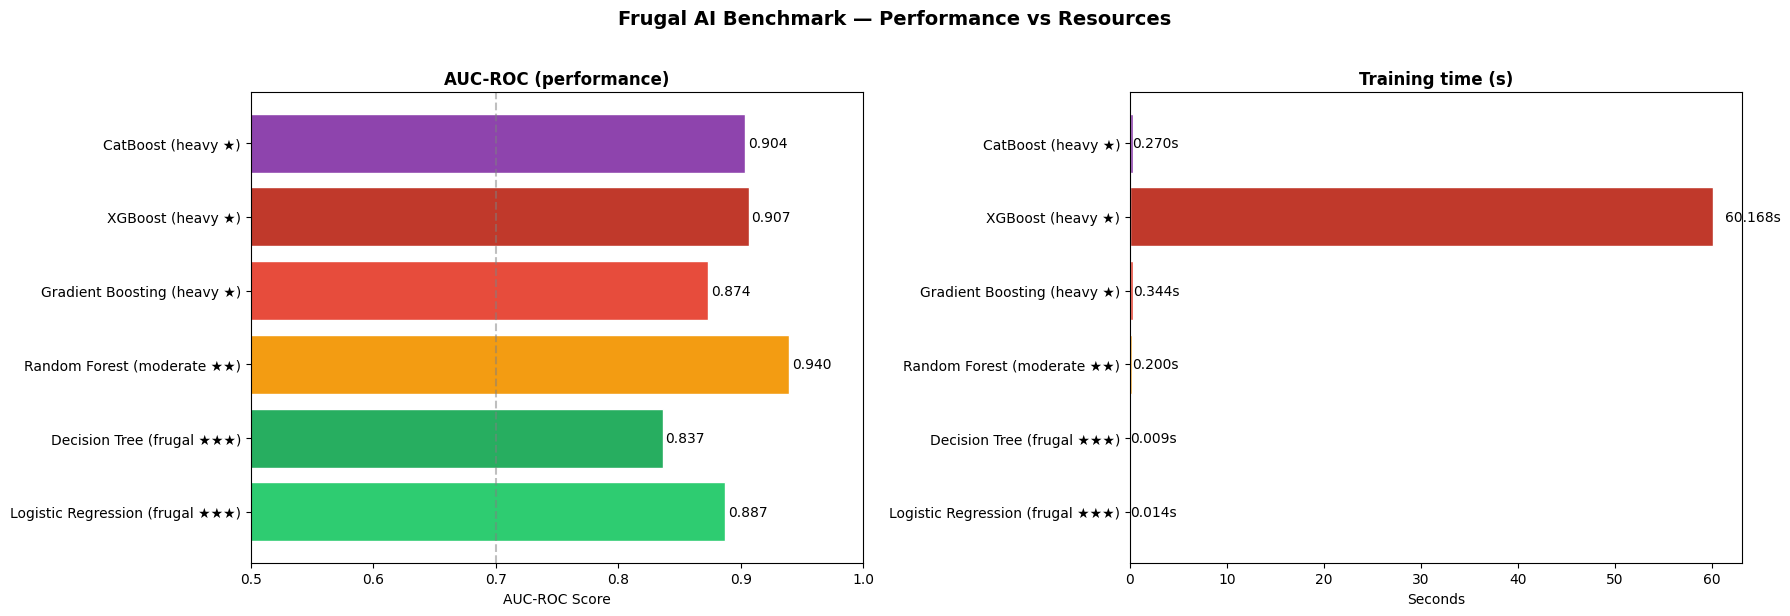

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
short_names = [n.replace('\n', ' ') for n in df_results['Model']]
palette = ['#2ecc71', '#27ae60', '#f39c12', '#e74c3c', '#c0392b', '#8e44ad']
colors = palette[:len(df_results)]

# AUC-ROC
ax = axes[0]
bars = ax.barh(short_names, df_results['AUC-ROC'], color=colors, edgecolor='white')
ax.set_xlim(0.5, 1.0)
ax.axvline(0.7, color='gray', linestyle='--', alpha=0.5, label='Acceptable threshold')
ax.set_title('AUC-ROC (performance)', fontweight='bold')
ax.set_xlabel('AUC-ROC Score')
for bar, val in zip(bars, df_results['AUC-ROC']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

# Training time
ax = axes[1]
bars = ax.barh(short_names, df_results['Time (s)'], color=colors, edgecolor='white')
ax.set_title("Training time (s)", fontweight='bold')
ax.set_xlabel('Seconds')
for bar, val in zip(bars, df_results['Time (s)']):
    ax.text(max(val * 1.02, ax.get_xlim()[0] + 0.001),
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}s', va='center', fontsize=10)


plt.suptitle('Frugal AI Benchmark — Performance vs Resources',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('frugal_benchmark.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Composite frugality score & Bubble chart

Composite frugality score (AUC / computational cost):
                            Model  AUC-ROC  Time (s)  frugality_score
     Random Forest\n(moderate ★★)   0.9396    0.1997           0.9099
Logistic Regression\n(frugal ★★★)   0.8874    0.0143           0.8853
              CatBoost\n(heavy ★)   0.9038    0.2697           0.8658
      Decision Tree\n(frugal ★★★)   0.8365    0.0091           0.8352
     Gradient Boosting\n(heavy ★)   0.8736    0.3438           0.8276
               XGBoost\n(heavy ★)   0.9066   60.1682           0.2668


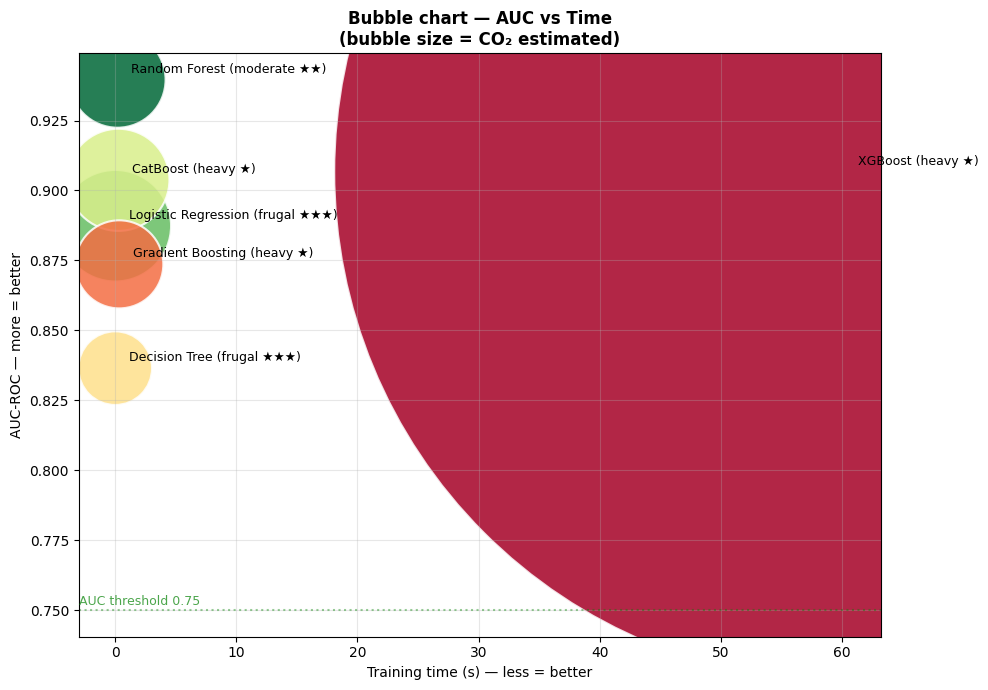


Recommended model (best frugality score): Random Forest (moderate ★★)


In [36]:
df_r = df_results.copy()
df_r['time_norm'] = df_r['Time (s)'] / df_r['Time (s)'].max()
df_r['frugality_score'] = (
    df_r['AUC-ROC'] / (1 + np.log1p(df_r['time_norm'] * 10))
).round(4)
df_r = df_r.sort_values('frugality_score', ascending=False)

print("Composite frugality score (AUC / computational cost):")
print(df_r[['Model', 'AUC-ROC', 'Time (s)', 'frugality_score']].to_string(index=False))

# Bubble chart
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    df_r['Time (s)'], df_r['AUC-ROC'],
    s=df_r['CO₂ estimated (g)'].apply(lambda x: max(150, x * 5e6)),
    c=range(len(df_r)), cmap='RdYlGn_r', alpha=0.85,
    edgecolors='white', linewidth=1.5
)
for _, row in df_r.iterrows():
    ax.annotate(
        row['Model'].replace('\n', ' '),
        (row['Time (s)'], row['AUC-ROC']),
        textcoords='offset points', xytext=(10, 5), fontsize=9
    )
ax.set_xlabel("Training time (s) — less = better")
ax.set_ylabel('AUC-ROC — more = better')
ax.set_title('Bubble chart — AUC vs Time\n(bubble size = CO₂ estimated)', fontweight='bold')
ax.axhline(0.75, color='green', linestyle=':', alpha=0.4)
ax.text(ax.get_xlim()[0], 0.752, 'AUC threshold 0.75', color='green', fontsize=9, alpha=0.7)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('frugal_bubble.png', dpi=120, bbox_inches='tight')
plt.show()

best = df_r.iloc[0]['Model'].replace('\n', ' ')
print(f"\nRecommended model (best frugality score): {best}")

## 6. Data frugality — How many features are needed?

Test if a reduced subset of features is enough to maintain good performance.  
Fewer features = less data collected, lower GDPR risk, lighter pipeline.

In [23]:
# Feature importance using Random Forest (to guide selection)
pipe_rf_base = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
])
pipe_rf_base.fit(X_train, y_train)
feat_importances = pipe_rf_base.named_steps['clf'].feature_importances_
feat_imp_df = pd.DataFrame({
    'feature': FEATURES_ALL,
    'importance': feat_importances
}).sort_values('importance', ascending=False)

print(feat_imp_df.to_string(index=False))

               feature  importance
     tenure_ratio_dept    0.231312
          tenure_years    0.219788
 manager_turnover_rate    0.078848
            risk_score    0.073470
     absences_per_year    0.065949
      EngagementSurvey    0.063235
              Absences    0.051073
            PositionID    0.042126
  SpecialProjectsCount    0.031837
     salary_ratio_dept    0.029006
       EmpSatisfaction    0.019870
               age_mid    0.018364
                DeptID    0.016656
        DaysLateLast30    0.015985
             MarriedID    0.013835
           PerfScoreID    0.013483
              GenderID    0.011843
      low_sat_high_abs    0.002186
FromDiversityJobFairID    0.001134


## 7. Export Random Forest model for webapp

In [27]:
import joblib
import json as _json

# Random Forest pipeline already trained
rf_pipeline = models['Random Forest\n(moderate ★★)']

joblib.dump(rf_pipeline, 'turnover_rf_pipeline.joblib')
print("Pipeline saved: turnover_rf_pipeline.joblib")

with open('features.json', 'w') as f:
    _json.dump(FEATURES_ALL, f, indent=2)
print(f"Features saved: features.json ({len(FEATURES_ALL)} features)")

example_row = X_test.iloc[0]
example_csv = ','.join(str(v) for v in example_row.values)
print(f"\nExample CSV row (for testing the webapp):")
print(f"  {','.join(FEATURES_ALL)}")
print(f"  {example_csv}")

Pipeline saved: turnover_rf_pipeline.joblib
Features saved: features.json (19 features)

Example CSV row (for testing the webapp):
  GenderID,MarriedID,PerfScoreID,FromDiversityJobFairID,DeptID,PositionID,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,DaysLateLast30,Absences,tenure_years,age_mid,salary_ratio_dept,risk_score,tenure_ratio_dept,manager_turnover_rate,absences_per_year,low_sat_high_abs
  0.0,0.0,3.0,0.0,5.0,20.0,4.4,5.0,0.0,0.0,1.0,5.253935660506502,34.5,1.1097345132743364,1.1999999999999997,0.8319605087438168,0.5454545454545454,0.1737940879081663,0.0
